In [4]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Subset

from dataset import TimeSeriesDataset, FeatureDescription
from model import TemporalFusionTransformer
from utils import load_config, find_quantile_index, unscale_per_id

In [5]:
CHECKPOINT_PATH = "runs_velib/20251230-113406/checkpoints/best.pt" 
CONFIG_PATH = "config.yaml"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
print("Loading configuration and data...")
config = load_config(CONFIG_PATH)
feature_cfg = config["feature_description"]
model_cfg = config["model"]
dataset_cfg = config["dataset"]
dataloader_cfg = config.get("dataloader", {})
batch_size = dataloader_cfg.get("batch_size", 64)
num_workers = dataloader_cfg.get("num_workers", 0)
pin_memory = dataloader_cfg.get("pin_memory", False)

feature_description = FeatureDescription(
    id=feature_cfg["id"],
    time=feature_cfg["time"],
    target=feature_cfg["target"],
    known_continuous=feature_cfg.get("known_continuous", []),
    known_categorical=feature_cfg.get("known_categorical", []),
    static_categorical=feature_cfg.get("static_categorical", []),
    static_continuous=feature_cfg.get("static_continuous", []),
    observed_continuous=feature_cfg.get("observed_continuous", []),
    observed_categorical=feature_cfg.get("observed_categorical", []),
)
if isinstance(feature_description.target, (list, tuple)):
    target_cols = list(feature_description.target)
else:
    target_cols = [feature_description.target]
missing_targets = [t for t in target_cols if t not in feature_description.observed_continuous]
if missing_targets:
    feature_description.observed_continuous = feature_description.observed_continuous + missing_targets

df = pd.read_csv(dataset_cfg["path"])

time_col = feature_description.time
valid_boundary = dataset_cfg["valid_boundary"]
test_boundary = dataset_cfg["test_boundary"]
step_seconds = dataset_cfg.get("step_seconds")
if step_seconds is None:
    time_values = (
        pd.to_numeric(df[time_col], errors="coerce")
        .dropna()
        .drop_duplicates()
        .sort_values()
    )
    if len(time_values) < 2:
        raise ValueError("Cannot infer step_seconds from time column; set dataset.step_seconds in config.")
    step_seconds = int(time_values.diff().median())
overlap = model_cfg["encoder_length"] * step_seconds

df_train = df[df[time_col] < valid_boundary]
df_val = df[(df[time_col] >= valid_boundary - overlap) & (df[time_col] < test_boundary)]
df_test = df[df[time_col] >= test_boundary - overlap]

id_col = feature_description.id
train_ids = set(df_train[id_col].unique())
df_val = df_val[df_val[id_col].isin(train_ids)]
df_test = df_test[df_test[id_col].isin(train_ids)]

train_dataset = TimeSeriesDataset(
    df=df_train,
    feature_description=feature_description,
    encoder_length=model_cfg["encoder_length"],
    decoder_length=model_cfg["decoder_length"],
)

categorical_encoder = train_dataset.categorical_encoder
real_scalers, target_scalers = TimeSeriesDataset.get_scalers(train_dataset)
target_scalers_by_id = {str(k): v for k, v in target_scalers.items()}

val_dataset = TimeSeriesDataset(
    df=df_val,
    feature_description=feature_description,
    encoder_length=model_cfg["encoder_length"],
    decoder_length=model_cfg["decoder_length"],
    categorical_encoder=categorical_encoder,
)
test_dataset = TimeSeriesDataset(
    df=df_test,
    feature_description=feature_description,
    encoder_length=model_cfg["encoder_length"],
    decoder_length=model_cfg["decoder_length"],
    categorical_encoder=categorical_encoder,
)

train_dataset.apply_scalers(real_scalers, target_scalers)
val_dataset.apply_scalers(real_scalers, target_scalers)
test_dataset.apply_scalers(real_scalers, target_scalers)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)


Loading configuration and data...


In [7]:
print("Loading model...")
params = {
    "encoder_length": model_cfg["encoder_length"],
    "decoder_length": model_cfg["decoder_length"],
    "time_steps": test_dataset.time_steps,
    "feature_description": feature_description,
    "embed_per_cat": test_dataset.get_embedding_per_cat(),
    "d_model": model_cfg["d_model"],
    "dropout": model_cfg["dropout"],
    "n_head": model_cfg["n_head"],
    "quantiles": model_cfg["quantiles"],
}

model = TemporalFusionTransformer(params).to(DEVICE)

# Load Weights
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    if "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"])
    else:
        model.load_state_dict(checkpoint)
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
else:
    print(f"WARNING: Checkpoint not found at {CHECKPOINT_PATH}")

Loading model...
Loaded checkpoint from runs_velib/20251230-113406/checkpoints/best.pt


In [ ]:
model.eval()
q_losses = {q: 0.0 for q in model.quantiles}
total_samples = 0
target_abs_sum = 0.0 

# Indices for P10, P50, P90
p10_idx = find_quantile_index(model.quantiles, 0.1)
p50_idx = find_quantile_index(model.quantiles, 0.5)
p90_idx = find_quantile_index(model.quantiles, 0.9)

# Store results for plotting
plot_data = []

# Variable importance accumulators
static_weights_list = []
hist_weights_list = []
fut_weights_list = []

static_features = feature_description.static_categorical + feature_description.static_continuous
hist_features = (
    feature_description.observed_categorical
    + feature_description.observed_continuous
    + feature_description.known_categorical
    + feature_description.known_continuous
)
fut_features = feature_description.known_categorical + feature_description.known_continuous

print("Running evaluation on Test Set...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        inputs = batch["model_inputs"]
        for k, v in inputs.items():
            inputs[k] = v.to(DEVICE)
        
        batch["model_inputs"] = inputs
        targets = batch["target"].to(DEVICE) 
        ids = batch["id"]
        
        # Forward pass with variable selection weights
        preds, weights = model(batch, return_weights=True)

        batch_static = weights["static"]
        if batch_static is not None:
            static_weights_list.append(batch_static.detach().cpu().numpy())

        batch_hist = weights["temporal_hist"]
        if batch_hist is not None:
            hist_weights_list.append(batch_hist.detach().cpu().numpy().reshape(-1, batch_hist.shape[-1]))

        batch_fut = weights["temporal_fut"]
        if batch_fut is not None:
            fut_weights_list.append(batch_fut.detach().cpu().numpy().reshape(-1, batch_fut.shape[-1]))
        
        # Unscale for accurate metrics and plotting
        preds_unscaled, targets_unscaled = unscale_per_id(preds, targets, ids, target_scalers_by_id)
        
        # Calculate qRisk 
        target_abs_sum += targets_unscaled.abs().sum().item()
        
        for i, q in enumerate(model.quantiles):
            errors = targets_unscaled - preds_unscaled[..., i:i+1]
            loss = torch.maximum(q * errors, (q - 1) * errors)
            q_losses[q] += loss.sum().item()
            
        total_samples += targets.shape[0]
        
        # Save first batch for plotting
        if len(plot_data) < 5:
            plot_data.append({
                "preds": preds_unscaled.cpu(),
                "targets": targets_unscaled.cpu(),
                "ids": ids,
                "time": batch["cut_time"]
            })


print("")
print("=== TEST SET RESULTS ===")
print("-" * 30)
for q in model.quantiles:
    # q-Risk formula: 2 * Sum(QuantileLoss) / Sum(Abs(Target))
    if target_abs_sum > 0:
        q_risk = 2.0 * q_losses[q] / target_abs_sum
        print(f"Quantile {q:.1f} | q-Risk: {q_risk:.5f}")
    else:
        print(f"Quantile {q:.1f} | q-Risk: N/A (Target abs sum is 0)")



def summarize_importance(weights_list, features, title):
    if not weights_list:
        return
    all_weights = np.concatenate(weights_list, axis=0)
    p10, p50, p90 = np.percentile(all_weights, [10, 50, 90], axis=0)
    importance = pd.DataFrame({
        "feature": features,
        "p10": p10,
        "p50": p50,
        "p90": p90,
    }).sort_values("p50", ascending=False)
    print("")
    print(title)
    print(importance)

summarize_importance(static_weights_list, static_features, "Static variable importance (p10/p50/p90):")
summarize_importance(hist_weights_list, hist_features, "Historical variable importance (p10/p50/p90):")
summarize_importance(fut_weights_list, fut_features, "Future variable importance (p10/p50/p90):")


Running evaluation on Test Set...


TypeError: 'DataLoader' object is not subscriptable

In [8]:
# Check dataset 
df = pd.read_csv('velib_data/velib_dataset.csv')

In [9]:
# Check station names and time interval
print(df["station_id"].unique())
print(df["date_seconds"].min(), df["date_seconds"].max())

[  97   31  221 ... 1325  742  545]
1606391940 1617971820


In [15]:
from torch.utils.data import Subset

station_name = "Benjamin Godard - Victor Hugo station"
station_id = "97"
# Test: 2021-03-26 18:36:00+00:00 - 2021-04-09 12:37:00+00:00
window_start = "2021-03-28T00:00"
window_end = "2021-03-29T00:00"

p10_idx = find_quantile_index(model.quantiles, 0.1)
p50_idx = find_quantile_index(model.quantiles, 0.5)
p90_idx = find_quantile_index(model.quantiles, 0.9)

if "real_scalers" not in globals() or "target_scalers_by_id" not in globals():
    real_scalers, target_scalers = TimeSeriesDataset.get_scalers(train_dataset)
    target_scalers_by_id = {str(k): v for k, v in target_scalers.items()}

real_scalers_by_id = {str(k): v for k, v in real_scalers.items()}
time_feature = feature_description.time
if time_feature in test_dataset.continuous_features:
    time_feature_idx = test_dataset.continuous_features.index(time_feature)
else:
    time_feature_idx = None

def to_timestamp(val):
    if isinstance(val, (int, float, np.integer, np.floating)):
        return pd.to_datetime(val, unit="s")
    try:
        return pd.to_datetime(float(val), unit="s")
    except (ValueError, TypeError):
        return pd.to_datetime(val)

def time_to_timestamp(val, id_str):
    numeric = None
    if isinstance(val, (int, float, np.integer, np.floating)):
        numeric = float(val)
    else:
        try:
            numeric = float(val)
        except (ValueError, TypeError):
            numeric = None
    if numeric is not None and time_feature_idx is not None:
        scaler = real_scalers_by_id.get(str(id_str))
        if scaler is not None:
            numeric = numeric * scaler.scale_[time_feature_idx] + scaler.mean_[time_feature_idx]
    if numeric is not None:
        return pd.to_datetime(numeric, unit="s")
    return pd.to_datetime(val)

window_start_ts = to_timestamp(window_start)
window_end_ts = to_timestamp(window_end)

print("")
print(f"Plotting forecasts for station {station_id} from {window_start_ts} to {window_end_ts}...")

sample_indices = []
for idx, (sid, t) in enumerate(test_dataset.samples):
    if str(sid) != str(station_id):
        continue
    cut_time_val = test_dataset.groups[sid][feature_description.time].iloc[t]
    cut_time_ts = time_to_timestamp(cut_time_val, sid)
    if window_start_ts <= cut_time_ts <= window_end_ts:
        sample_indices.append(idx)

if not sample_indices:
    print(f"No samples found for station {station_id} in [{window_start}, {window_end}].")
else:
    subset_loader = DataLoader(
        Subset(test_dataset, sample_indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    records = []
    with torch.no_grad():
        for batch in subset_loader:
            inputs = batch["model_inputs"]
            for k, v in inputs.items():
                inputs[k] = v.to(DEVICE)

            batch["model_inputs"] = inputs
            targets = batch["target"].to(DEVICE)
            ids = batch["id"]

            preds = model(batch)
            preds_unscaled, targets_unscaled = unscale_per_id(preds, targets, ids, target_scalers_by_id)

            for i, cut_time in enumerate(batch["cut_time"]):
                cut_time_ts = time_to_timestamp(cut_time, ids[i])
                times = [
                    cut_time_ts + pd.Timedelta(seconds=step_seconds * j)
                    for j in range(targets_unscaled.shape[1])
                ]
                for j, ts in enumerate(times):
                    if window_start_ts <= ts <= window_end_ts:
                        records.append({
                            "time": ts,
                            "actual": float(targets_unscaled[i, j, 0].cpu().item()),
                            "p10": float(preds_unscaled[i, j, p10_idx].cpu().item()) if p10_idx is not None else np.nan,
                            "p50": float(preds_unscaled[i, j, p50_idx].cpu().item()) if p50_idx is not None else np.nan,
                            "p90": float(preds_unscaled[i, j, p90_idx].cpu().item()) if p90_idx is not None else np.nan,
                        })

    if not records:
        print(f"No forecast points in range for station {station_id}.")
    else:
        plot_df = (
            pd.DataFrame(records)
            .groupby("time", as_index=False)
            .mean()
            .sort_values("time")
        )



Plotting forecasts for station 97 from 2021-03-28 00:00:00 to 2021-03-29 00:00:00...


/home/daniel/miniconda3/envs/kvae310/lib/python3.10/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


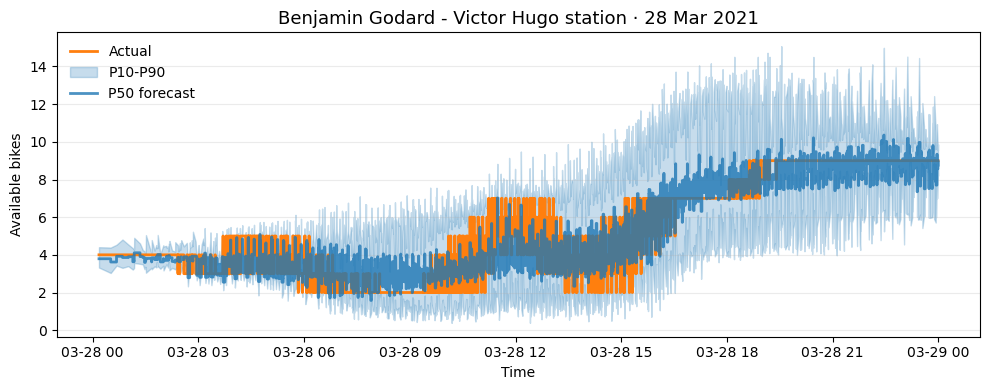

In [47]:
import numpy as np
import matplotlib.pyplot as plt

time = plot_df["time"]
actual = plot_df["actual"]
p50 = plot_df["p50"]
p10 = plot_df["p10"]
p90 = plot_df["p90"]

plt.figure(figsize=(10, 4))

# Actual (strongest visual weight)
plt.step(
    time, actual,
    where="post",
    label="Actual",
    color="tab:orange",
    linewidth=2
)

# Uncertainty band
plt.fill_between(
    time,
    np.minimum(p10, p90),
    np.maximum(p10, p90),
    color="tab:blue",
    alpha=0.25,
    label="P10-P90"
)


# Median forecast
plt.step(
    time, p50,
    where="post",
    label="P50 forecast",
    color="tab:blue",
    alpha=0.8,
    linewidth=2,
)

plt.title(f"{station_name} · 28 Mar 2021", fontsize=13)
plt.xlabel("Time")
plt.ylabel("Available bikes")

plt.legend(frameon=False)
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
